# Mixed Workload Analysis Entrypoint

Use this notebook to inspect sweep outputs, regenerate quick plots, and draft findings for `docs/results.md`.

In [5]:
from __future__ import annotations

import csv
from pathlib import Path

import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

BASELINE = ROOT / 'results' / 'sweep.csv'
CONTENTION = ROOT / 'results' / 'high_contention_sweep.csv'

print('Root:', ROOT)
print('Baseline CSV exists:', BASELINE.exists())
print('High-contention CSV exists:', CONTENTION.exists())

Root: /Users/aaliyan/aaliyan/mixed-workload-serving-benchmark
Baseline CSV exists: True
High-contention CSV exists: True


In [6]:
def load_rows(path: Path) -> list[dict[str, float | str]]:
    rows: list[dict[str, float | str]] = []
    with path.open(newline='') as fp:
        reader = csv.DictReader(fp)
        for raw in reader:
            rows.append({
                'policy': raw['policy'],
                'streaming_ratio': float(raw['streaming_ratio']),
                'agentic_ratio': float(raw['agentic_ratio']),
                'throughput_rps': float(raw['throughput_rps']),
                'throughput_rps_ci95': float(raw.get('throughput_rps_ci95', 0.0)),
                'p95_latency_ms': float(raw['p95_latency_ms']),
                'p95_latency_ms_ci95': float(raw.get('p95_latency_ms_ci95', 0.0)),
                'sla_violation_rate': float(raw['sla_violation_rate']),
                'sla_violation_rate_ci95': float(raw.get('sla_violation_rate_ci95', 0.0)),
                'cost_per_success': float(raw['cost_per_success']),
                'cost_per_success_ci95': float(raw.get('cost_per_success_ci95', 0.0)),
            })
    return rows

baseline_rows = load_rows(BASELINE)
contention_rows = load_rows(CONTENTION)

print('Baseline rows:', len(baseline_rows))
print('High-contention rows:', len(contention_rows))

Baseline rows: 9
High-contention rows: 9


In [7]:
def best_policy(rows: list[dict[str, float | str]], metric: str, direction: str) -> str:
    if direction == 'higher':
        row = max(rows, key=lambda r: float(r[metric]))
    else:
        row = min(rows, key=lambda r: float(r[metric]))
    return str(row['policy'])

metrics = [
    ('throughput_rps', 'higher'),
    ('p95_latency_ms', 'lower'),
    ('sla_violation_rate', 'lower'),
    ('cost_per_success', 'lower'),
]

print('Baseline winners')
for key, direction in metrics:
    print(f'  {key}: {best_policy(baseline_rows, key, direction)}')

print('\nHigh-contention winners')
for key, direction in metrics:
    print(f'  {key}: {best_policy(contention_rows, key, direction)}')

Baseline winners
  throughput_rps: fifo
  p95_latency_ms: shortest-job-first
  sla_violation_rate: shortest-job-first
  cost_per_success: fifo

High-contention winners
  throughput_rps: shortest-job-first
  p95_latency_ms: shortest-job-first
  sla_violation_rate: shortest-job-first
  cost_per_success: shortest-job-first


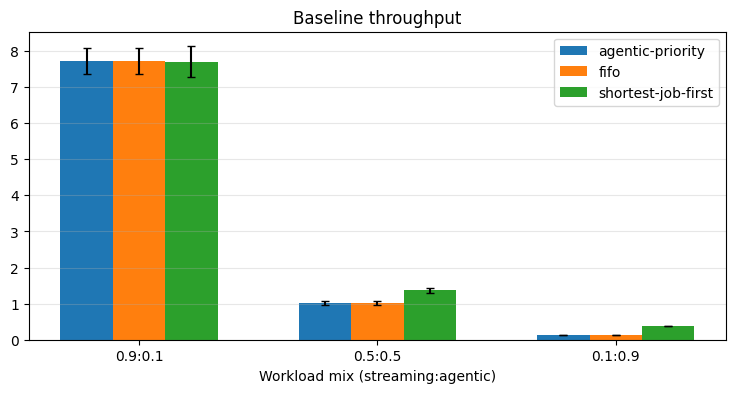

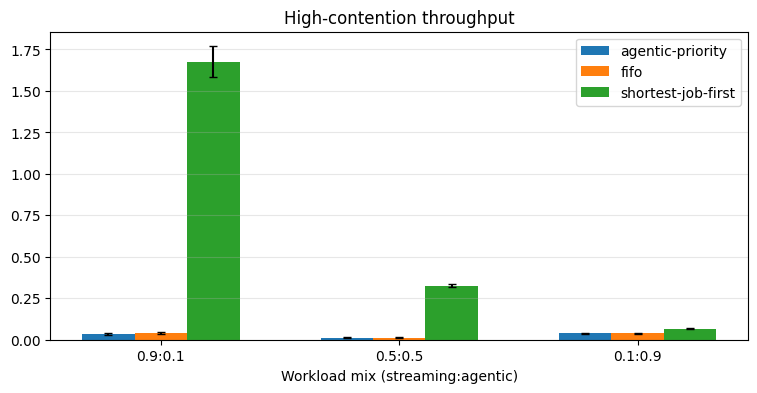

In [8]:
def plot_metric(rows: list[dict[str, float | str]], metric: str, ci_metric: str, title: str) -> None:
    policies = sorted({str(r['policy']) for r in rows})
    mixes = sorted({float(r['streaming_ratio']) for r in rows}, reverse=True)

    width = 0.22
    x = list(range(len(mixes)))

    fig, ax = plt.subplots(figsize=(9, 4))
    for i, policy in enumerate(policies):
        ys = []
        errs = []
        for mix in mixes:
            row = next(r for r in rows if r['policy'] == policy and r['streaming_ratio'] == mix)
            ys.append(float(row[metric]))
            errs.append(float(row[ci_metric]))
        offset = [v + (i - (len(policies) - 1) / 2) * width for v in x]
        ax.bar(offset, ys, width=width, yerr=errs, capsize=3, label=policy)

    labels = [f'{m:.1f}:{1.0 - m:.1f}' for m in mixes]
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_xlabel('Workload mix (streaming:agentic)')
    ax.set_title(title)
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend()
    plt.show()

plot_metric(baseline_rows, 'throughput_rps', 'throughput_rps_ci95', 'Baseline throughput')
plot_metric(contention_rows, 'throughput_rps', 'throughput_rps_ci95', 'High-contention throughput')

## Findings Draft Prompts

Use these prompts to write your short report:

- Which policy dominates in baseline vs high-contention?
- Where does tail latency degrade fastest as agentic ratio rises?
- How do SLA violations track with cost-per-success under contention?
- What deployment recommendation follows for mixed traffic systems?

Then transfer your polished text into `docs/results.md` and `docs/technical_note_template.md`.